# Bradley-Terry gerarchico VGC — analisi dei risultati

Modello bayesiano di ranking per il metagame VGC (Reg M-B, Mondiali 2026).
La forza di una squadra e' decomposta in effetti di **specie, mosse, abilita', strumenti, nature**,
piu' un effetto **pilota**. Questo notebook carica il posterior gia' stimato (`bt_posterior.nc`)
e produce le classifiche con incertezza.

Prerequisiti: aver lanciato
`python bt_bayes.py --matches data/matches_clean.jsonl --method advi --min-freq 5`
(o `--method nuts` per le stime finali).

In [ ]:
# --- setup percorsi (rende il notebook eseguibile da notebooks/) ---
import sys, os
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":            # se aperto da notebooks/, risali alla radice
    ROOT = ROOT.parent
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))   # rende importabili design_matrix, bt_bayes, ...

DATA    = ROOT / "data"
MODELS  = ROOT / "models";  MODELS.mkdir(exist_ok=True)
RESULTS = ROOT / "results"; RESULTS.mkdir(exist_ok=True)
FIGURES = ROOT / "figures"; FIGURES.mkdir(exist_ok=True)
print("radice progetto:", ROOT)

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

from design_matrix import ALL_BLOCKS, team_counts, load_matches
import os
pass  # cartelle create nella cella di setup

idata = az.from_netcdf(MODELS / "bt_posterior.nc")
artifacts = json.load(open(MODELS / "bt_artifacts.json", encoding="utf-8"))
vocab = {b: {lv: i for i, lv in enumerate(artifacts["vocab"][b])} for b in ALL_BLOCKS}

matches = load_matches(DATA / "matches_clean.jsonl")
teams_rows = [json.loads(l) for l in open(DATA / "teams.jsonl", encoding="utf-8")]
print("blocchi:", {b: len(artifacts["vocab"][b]) for b in ALL_BLOCKS})
print("giocatori:", len(artifacts["players"]), "| match:", len(matches), "| team-righe:", len(teams_rows))

blocchi: {'species': 219, 'ability': 168, 'item': 162, 'nature': 23, 'moves': 420}
giocatori: 3878 | match: 17581 | team-righe: 7025


## Funzioni di supporto
`summarize` riassume un blocco di coefficienti (media, sd, intervallo 5-95%).
`block_samples` estrae i campioni del posterior per il calcolo vettoriale della forza-squadra.

In [2]:
def summarize(varname, dim):
    da = idata.posterior[varname].stack(sample=("chain", "draw"))
    v = da.values  # (n_livelli, S)
    df = pd.DataFrame({
        "mean": v.mean(1), "sd": v.std(1),
        "q5": np.percentile(v, 5, axis=1), "q95": np.percentile(v, 95, axis=1),
    }, index=[str(x) for x in da[dim].values])
    return df.sort_values("mean", ascending=False)

def block_samples(block):
    da = idata.posterior[f"beta_{block}"].stack(sample=("chain", "draw"))
    idx = {str(lv): i for i, lv in enumerate(da[block].values)}
    return da.values, idx  # (n_livelli, S), {label: riga}

def forest(df, title, n=20, fname=None):
    top = pd.concat([df.head(n), df.tail(n)])
    y = np.arange(len(top))[::-1]
    fig, ax = plt.subplots(figsize=(7, max(4, len(top) * 0.28)))
    ax.errorbar(top["mean"], y,
                xerr=[top["mean"] - top["q5"], top["q95"] - top["mean"]],
                fmt="o", ms=4, lw=1, color="#3b5bdb")
    ax.axvline(0, color="grey", lw=0.8, ls="--")
    ax.set_yticks(y); ax.set_yticklabels(top.index, fontsize=8)
    ax.set_title(title); ax.set_xlabel("effetto sulla forza (log-odds)")
    plt.tight_layout()
    if fname: plt.savefig(FIGURES / fname, dpi=130)
    plt.show()

## 1. Quali dimensioni contano — le scale `tau`
`tau_b` e' la deviazione standard degli effetti di ciascun blocco: piu' e' grande,
piu' quella dimensione muove la forza. Se `tau_species` domina, il segnale e' quasi
tutto a livello Pokemon; se mosse/strumenti hanno `tau` confrontabili, il set conta.

,mean,q5,q95
blocco,,,
player,1.074438,1.051673,1.096287
item,0.213376,0.191798,0.234963
species,0.200930,0.183891,0.219450
ability,0.194092,0.176005,0.213102
moves,0.186657,0.174931,0.198885
nature,0.121306,0.087890,0.158244


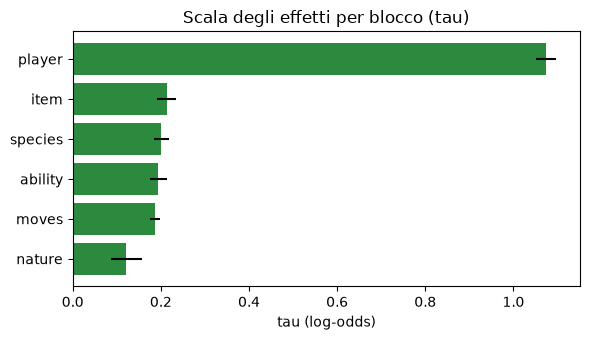

In [3]:
tau_vars = [f"tau_{b}" for b in ALL_BLOCKS] + ["tau_player"]
rows = []
for v in tau_vars:
    s = idata.posterior[v].stack(sample=("chain", "draw")).values.ravel()
    rows.append((v.replace("tau_", ""), s.mean(), np.percentile(s, 5), np.percentile(s, 95)))
tau_df = pd.DataFrame(rows, columns=["blocco", "mean", "q5", "q95"]).set_index("blocco")
display(tau_df.sort_values("mean", ascending=False))

fig, ax = plt.subplots(figsize=(6, 3.5))
order = tau_df.sort_values("mean")
ax.barh(order.index, order["mean"],
        xerr=[order["mean"] - order["q5"], order["q95"] - order["mean"]],
        color="#2b8a3e")
ax.set_title("Scala degli effetti per blocco (tau)"); ax.set_xlabel("tau (log-odds)")
plt.tight_layout(); plt.savefig(FIGURES / "tau_blocchi.png", dpi=130); plt.show()

## 2. Ranking dei Pokemon (effetto specie)
`beta_species` e' il contributo di ciascuna specie alla forza della squadra, a parita'
di tutto il resto. E' la classifica "quale Pokemon rende piu' forte una squadra".

,mean,sd,q5,q95
Armarouge,0.255,0.173,-0.007,0.536
Gallade,0.216,0.125,0.013,0.420
Charizard,0.202,0.060,0.103,0.294
Gardevoir,0.199,0.099,0.043,0.362
Froslass,0.199,0.076,0.081,0.327
Wash Rotom,0.174,0.076,0.051,0.297
Toxapex,0.174,0.105,0.005,0.353
Klefki,0.173,0.187,-0.128,0.475
Crabominable,0.169,0.183,-0.143,0.474
Snorlax,0.162,0.148,-0.077,0.408


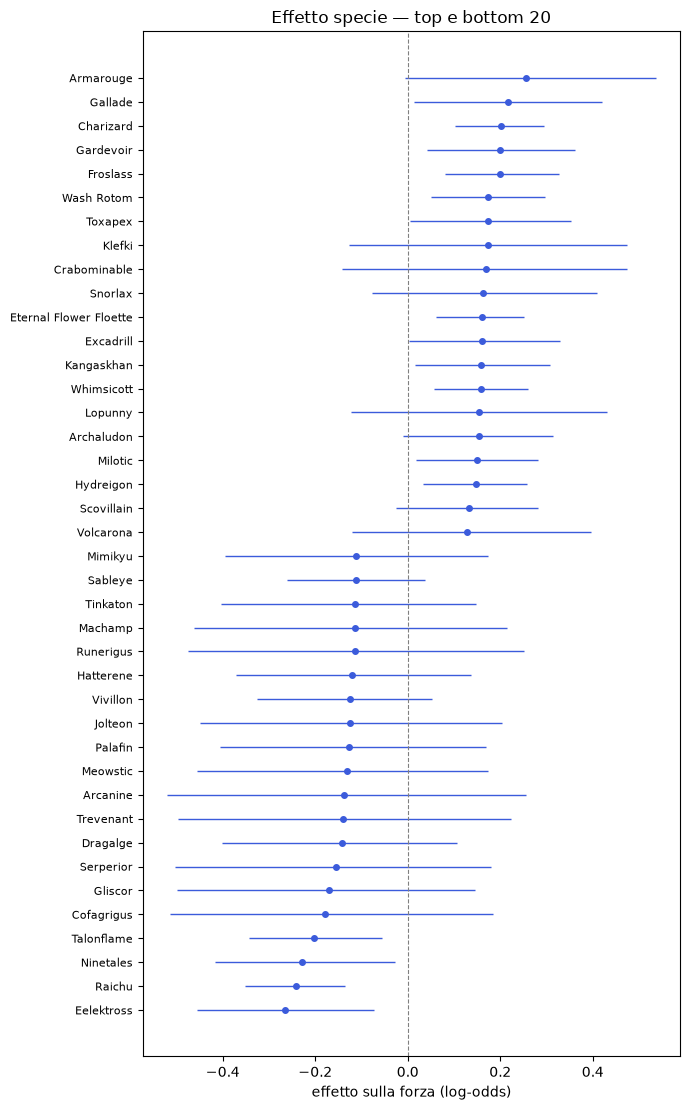

In [4]:
sp = summarize("beta_species", "species")
display(sp.head(20).round(3))
forest(sp, "Effetto specie — top e bottom 20", n=20, fname="ranking_specie.png")
sp.to_csv(RESULTS / "ranking_specie.csv")

## 3. Effetti di set — strumenti, mosse, abilita', nature
Nota gli item nuovi di Champions (le Mega Stone tipo `Floettite`) e `No Item` come
livelli veri. Per mosse/abilita' molti effetti sono vicini a zero: e' lo shrinkage
che agisce sui livelli poco informativi.

== Strumenti: top 12 ==


,mean,sd,q5,q95
Venusaurite,0.368,0.083,0.233,0.504
Spell Tag,0.234,0.123,0.032,0.435
Floettite,0.206,0.060,0.104,0.299
Raichunite Y,0.197,0.070,0.080,0.314
Dragoninite,0.187,0.096,0.022,0.347
Crabominite,0.169,0.196,-0.140,0.478
Black Sludge,0.163,0.228,-0.218,0.533
Light Clay,0.159,0.076,0.034,0.286
Black Glasses,0.155,0.054,0.066,0.239
Lopunnite,0.154,0.176,-0.137,0.437


== Mosse: top 12 ==


,mean,sd,q5,q95
Quick Guard,0.251,0.097,0.083,0.408
Perish Song,0.237,0.065,0.130,0.341
Psych Up,0.232,0.158,-0.018,0.497
Gunk Shot,0.231,0.113,0.041,0.414
Snarl,0.229,0.069,0.113,0.338
Spirit Break,0.206,0.075,0.090,0.334
Encore,0.202,0.052,0.120,0.279
Weather Ball,0.202,0.049,0.125,0.279
Freeze-Dry,0.177,0.081,0.036,0.307
Electroweb,0.172,0.096,0.018,0.329


== Abilita': top 12 ==


,mean,sd,q5,q95
Moody,0.289,0.098,0.124,0.456
Overcoat,0.240,0.174,-0.041,0.515
Competitive,0.224,0.084,0.076,0.361
Telepathy,0.211,0.146,-0.033,0.462
Scrappy,0.193,0.089,0.044,0.333
Unnerve,0.184,0.058,0.086,0.287
Huge Power,0.170,0.150,-0.062,0.430
Friend Guard,0.167,0.079,0.037,0.294
Flame Body,0.161,0.153,-0.088,0.418
Snow Warning,0.160,0.071,0.050,0.274


== Nature: tutte ==


,mean,sd,q5,q95
Calm,0.184,0.044,0.111,0.256
Bold,0.101,0.033,0.047,0.153
Modest,0.090,0.025,0.048,0.132
Adamant,0.061,0.025,0.018,0.102
Mild,0.047,0.122,-0.149,0.250
Jolly,0.033,0.026,-0.009,0.075
Impish,0.029,0.047,-0.046,0.106
Naive,0.011,0.110,-0.179,0.184
Lax,0.010,0.127,-0.196,0.214
Timid,0.006,0.083,-0.134,0.140


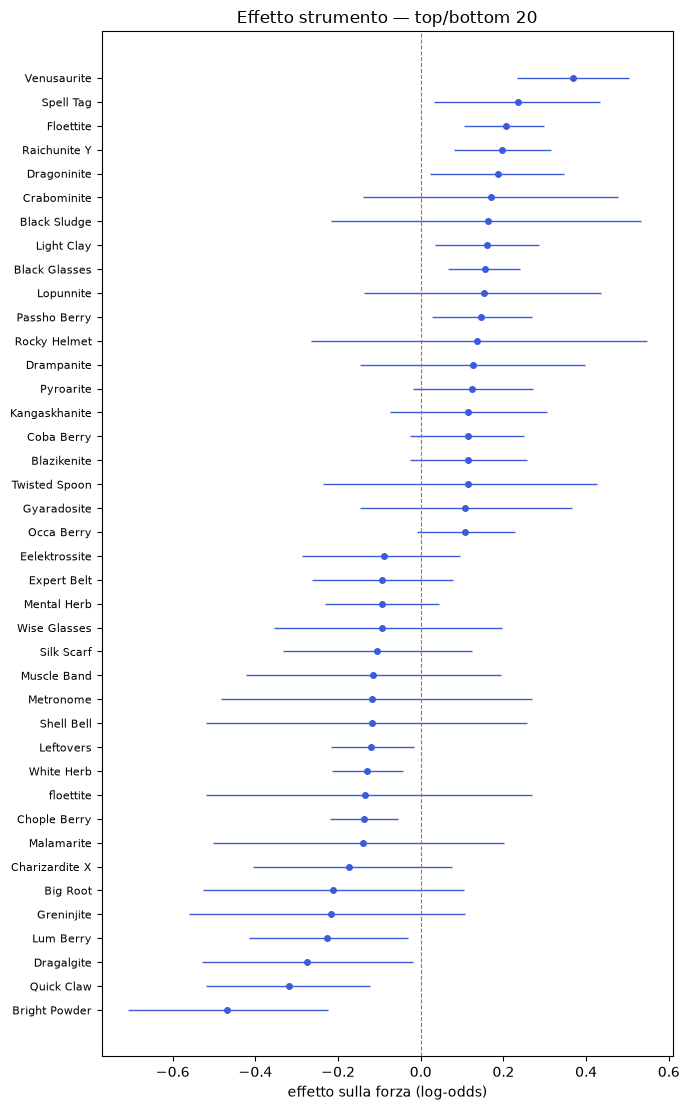

In [5]:
it = summarize("beta_item", "item")
mv = summarize("beta_moves", "moves")
ab = summarize("beta_ability", "ability")
na = summarize("beta_nature", "nature")

print("== Strumenti: top 12 ==");  display(it.head(12).round(3))
print("== Mosse: top 12 ==");      display(mv.head(12).round(3))
print("== Abilita': top 12 ==");   display(ab.head(12).round(3))
print("== Nature: tutte ==");      display(na.round(3))

forest(it, "Effetto strumento — top/bottom 20", n=20, fname="ranking_item.png")
for df, nm in [(it, "item"), (mv, "moves"), (ab, "ability"), (na, "nature")]:
    df.to_csv(RESULTS / f"ranking_{nm}.csv")

## 4. Effetto pilota
`lam_player` separa l'abilita' del giocatore dalla forza della squadra. Serve per
non confondere "team forte" con "pilotato bene".

**Cautela di identificabilita':** se un giocatore porta quasi sempre lo stesso team,
la sua `lam` e la forza di quel team sono collineari e vanno lette con prudenza.

In [6]:
lam = summarize("lam_player", "player")
print("Top 15 piloti per effetto stimato:")
display(lam.head(15).round(3))
print(f"\nDispersione degli effetti pilota: sd = {lam['mean'].std():.3f}")

Top 15 piloti per effetto stimato:


,mean,sd,q5,q95
vgcorner,2.744,0.629,1.715,3.789
mollusck,2.667,0.760,1.408,3.866
magicaura,2.599,0.633,1.543,3.704
force_india,2.536,0.460,1.775,3.309
joeux9,2.529,0.587,1.504,3.479
wb_vg,2.518,0.404,1.883,3.180
michaelderbeste,2.513,0.639,1.484,3.545
magnetman,2.315,0.555,1.421,3.222
tytokiarts,2.314,0.683,1.193,3.411
verdianhatake,2.288,0.544,1.392,3.169



Dispersione degli effetti pilota: sd = 0.733


## 5. Squadre favorite (il target)
Per ogni squadra osservata calcoliamo la distribuzione a posteriori di `s(team)`
(senza la componente pilota) e la ordiniamo. Ci limitiamo alle squadre che compaiono
almeno `MIN_OCC` volte, per rankare archetipi reali e non liste uniche.

In [7]:
MIN_OCC = 5

def team_key(team):
    return tuple(sorted(
        (m["species"], m.get("item"), m.get("ability"), m.get("nature"),
         tuple(sorted(m.get("moves", [])))) for m in team))

# raccogli team unici e frequenza
uniq = {}
for r in teams_rows:
    k = team_key(r["team"])
    if k not in uniq:
        uniq[k] = {"team": r["team"], "n": 0}
    uniq[k]["n"] += 1
cand = [v for v in uniq.values() if v["n"] >= MIN_OCC]
print(f"{len(cand)} squadre con almeno {MIN_OCC} presenze (su {len(uniq)} uniche)")

# forza-squadra vettoriale: per blocco, matrice conteggi (T x livelli) @ campioni beta (livelli x S)
betas = {b: block_samples(b) for b in ALL_BLOCKS}
S = next(iter(betas.values()))[0].shape[1]
strength = np.zeros((len(cand), S))
for b in ALL_BLOCKS:
    B, idx = betas[b]
    C = np.zeros((len(cand), B.shape[0]))
    for i, v in enumerate(cand):
        c = team_counts(v["team"])[b]
        for lv, n in c.items():
            j = idx.get(str(lv))
            if j is not None: C[i, j] += n
    strength += C @ B  # (T x S)

rank = pd.DataFrame({
    "n": [v["n"] for v in cand],
    "mean": strength.mean(1),
    "q5": np.percentile(strength, 5, axis=1),
    "q95": np.percentile(strength, 95, axis=1),
}).sort_values("mean", ascending=False).reset_index(drop=True)

def team_label(team):
    return " / ".join(m["species"] for m in team)
rank["squadra"] = [team_label(cand_sorted["team"]) for cand_sorted in
                   [cand[i] for i in np.argsort(-strength.mean(1))]]
display(rank.head(20)[["squadra", "n", "mean", "q5", "q95"]].round(3))
rank.to_csv(RESULTS / "ranking_squadre.csv", index=False)

95 squadre con almeno 5 presenze (su 5393 uniche)


,squadra,n,mean,q5,q95
0,Sneasler / Blastoise / Kingambit / Incineroar ...,7,2.923,2.132,3.684
1,Blastoise / Delphox / Sneasler / Incineroar / ...,5,2.731,1.914,3.530
2,Froslass / Scovillain / Basculegion / Kingambi...,8,2.665,1.946,3.418
3,Delphox / Eternal Flower Floette / Sinistcha /...,7,2.593,1.872,3.308
4,Sinistcha / Kingambit / Sneasler / Eternal Flo...,8,2.556,1.851,3.269
5,Froslass / Scovillain / Sneasler / Kingambit /...,7,2.354,1.661,3.100
6,Charizard / Sylveon / Aerodactyl / Farigiraf /...,5,2.337,1.680,3.046
7,Swampert / Pelipper / Archaludon / Venusaur / ...,7,2.326,1.450,3.161
8,Charizard / Aerodactyl / Farigiraf / Garchomp ...,6,2.324,1.659,3.018
9,Sinistcha / Incineroar / Milotic / Raichu / Et...,21,2.298,1.467,3.156


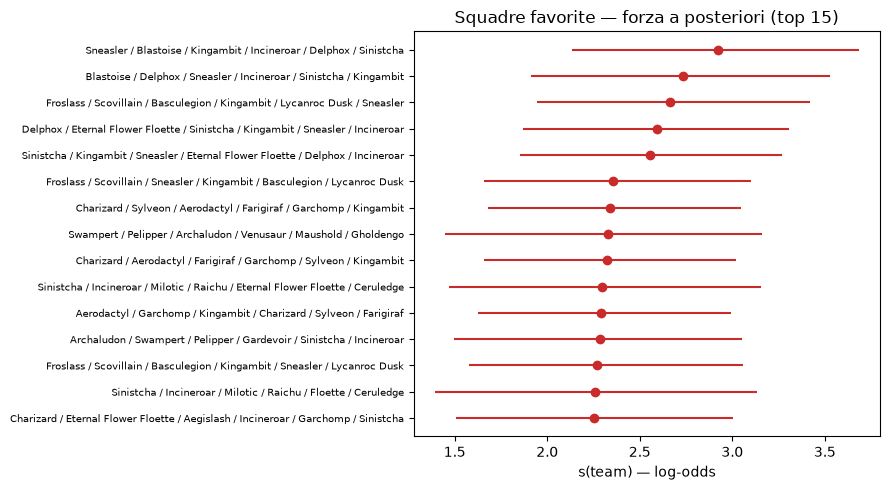

In [8]:
# forest plot delle top 15 squadre
top = rank.head(15)[::-1]
y = np.arange(len(top))
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(top["mean"], y, xerr=[top["mean"] - top["q5"], top["q95"] - top["mean"]],
            fmt="o", color="#c92a2a")
ax.set_yticks(y); ax.set_yticklabels(top["squadra"], fontsize=7)
ax.set_title("Squadre favorite — forza a posteriori (top 15)")
ax.set_xlabel("s(team) — log-odds")
plt.tight_layout(); plt.savefig(FIGURES / "ranking_squadre.png", dpi=130); plt.show()

## 6. Testa a testa
Probabilita' a posteriori che la squadra A batta la B, a parita' di pilota:
`P(A>B) = media_draw sigmoid(s_A - s_B)`. Qui confrontiamo le prime due in classifica.

A: Sneasler / Blastoise / Kingambit / Incineroar / Delphox / Sinistcha
B: Blastoise / Delphox / Sneasler / Incineroar / Sinistcha / Kingambit
P(A batte B) = 0.547  (intervallo 5-95%: 0.476-0.622)


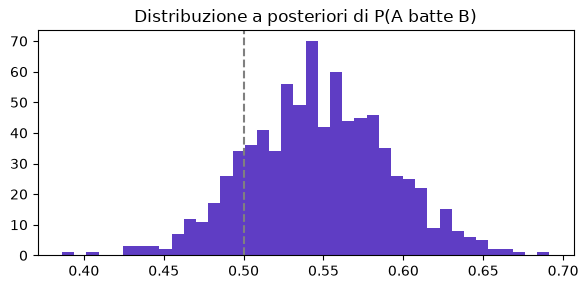

In [9]:
ia, ib = 0, 1  # indici in 'rank' (gia' ordinata per forza)
# ricostruisci l'ordine di 'strength' coerente con 'rank'
order = np.argsort(-strength.mean(1))
sA = strength[order[ia]]; sB = strength[order[ib]]
diff = sA - sB
p = 1 / (1 + np.exp(-diff))
print(f"A: {rank.iloc[ia]['squadra']}")
print(f"B: {rank.iloc[ib]['squadra']}")
print(f"P(A batte B) = {p.mean():.3f}  (intervallo 5-95%: "
      f"{np.percentile(p,5):.3f}-{np.percentile(p,95):.3f})")

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(p, bins=40, color="#5f3dc4")
ax.axvline(0.5, color="grey", ls="--")
ax.set_title("Distribuzione a posteriori di P(A batte B)")
plt.tight_layout(); plt.show()

## 7. Validazione held-out
L'ADVI e in-sample non dicono se il modello *predice*. Qui separiamo train/test,
**ririfittiamo l'ADVI sul solo train** (vocabolario ricostruito sul train per evitare
leakage) e misuriamo log-loss e accuratezza sul test, piu' la calibrazione.

E' piu' lento (rifà un fit). Saltala se vuoi solo le classifiche.

In [10]:
import pymc as pm
from design_matrix import build_vocabs, build_matrices
from bt_bayes import make_model

rng = np.random.default_rng(0)
perm = rng.permutation(len(matches))
cut = int(0.85 * len(matches))
train = [matches[i] for i in perm[:cut]]
test  = [matches[i] for i in perm[cut:]]

mf = artifacts["min_freq"]
vtr, _ = build_vocabs(train, mf)
Xtr, p1tr, p2tr, ytr, players_tr, inv_tr = build_matrices(train, vtr)
labels_tr = {b: list(vtr[b].keys()) for b in ALL_BLOCKS}
plabels_tr = [inv_tr[i] for i in range(len(players_tr))]

with make_model(Xtr, p1tr, p2tr, ytr, labels_tr, plabels_tr):
    approx = pm.fit(20000, method="advi")
    idata_tr = approx.sample(400)
print("refit sul train completato")

c:\Users\mmore\anaconda3\envs\vgc\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter
support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\mmore\anaconda3\envs\vgc\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter
support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\mmore\anaconda3\envs\vgc\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter
support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\mmore\anaconda3\envs\vgc\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter
support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\mmore\anaconda3\envs\vgc\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter
support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

c:\Users\mmore\anaconda3\envs\vgc\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter
support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\mmore\anaconda3\envs\vgc\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter
support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\mmore\anaconda3\envs\vgc\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 11,614


refit sul train completato


In [11]:
# predizione sul test, mediando sigmoid sui draw
post = idata_tr.posterior
betas_tr = {b: post[f"beta_{b}"].stack(sample=("chain", "draw")).values for b in ALL_BLOCKS}
lam_tr = post["lam_player"].stack(sample=("chain", "draw")).values
cside = post["c_side"].stack(sample=("chain", "draw")).values.ravel()
pmap = {p: i for i, p in enumerate(plabels_tr)}

def predict(ms):
    P = np.empty(len(ms))
    for i, m in enumerate(ms):
        eta = cside.copy()
        c1 = team_counts(m["team1"]); c2 = team_counts(m["team2"])
        for b in ALL_BLOCKS:
            vb = vtr[b]; vec = np.zeros(len(vb))
            for lv, n in c1[b].items():
                j = vb.get(lv)
                if j is not None: vec[j] += n
            for lv, n in c2[b].items():
                j = vb.get(lv)
                if j is not None: vec[j] -= n
            eta = eta + vec @ betas_tr[b]
        i1 = pmap.get(m["player1"]); i2 = pmap.get(m["player2"])
        if i1 is not None: eta = eta + lam_tr[i1]
        if i2 is not None: eta = eta - lam_tr[i2]
        P[i] = (1 / (1 + np.exp(-eta))).mean()
    return P

Pte = predict(test)
yte = np.array([m["label"] for m in test])
eps = 1e-9
logloss = -np.mean(yte * np.log(Pte + eps) + (1 - yte) * np.log(1 - Pte + eps))
acc = np.mean((Pte > 0.5) == yte)
print(f"test log-loss: {logloss:.4f}  (baseline coin-flip = {np.log(2):.4f})")
print(f"test accuracy: {acc:.4f}")

test log-loss: 0.6618  (baseline coin-flip = 0.6931)
test accuracy: 0.6141


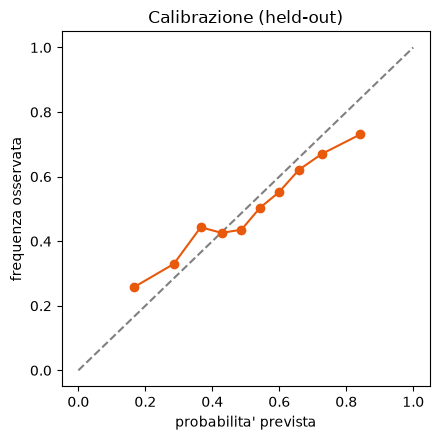

In [12]:
# curva di calibrazione (decili di probabilita' prevista)
bins = np.quantile(Pte, np.linspace(0, 1, 11))
bins[0], bins[-1] = 0, 1
mid, obs = [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    sel = (Pte >= lo) & (Pte < hi)
    if sel.sum() > 0:
        mid.append(Pte[sel].mean()); obs.append(yte[sel].mean())
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot([0, 1], [0, 1], "--", color="grey")
ax.plot(mid, obs, "o-", color="#e8590c")
ax.set_xlabel("probabilita' prevista"); ax.set_ylabel("frequenza osservata")
ax.set_title("Calibrazione (held-out)")
plt.tight_layout(); plt.savefig(FIGURES / "calibrazione.png", dpi=130); plt.show()

## Note per l'analisi finale
- L'ADVI e' un'approssimazione mean-field (ignora le correlazioni a posteriori e
  tende a sottostimare l'incertezza). Per le stime definitive rilancia con
  `--method nuts`: gli intervalli credibili si allargano e diventano affidabili.
- Se in classifica una squadra forte pilotata da un solo giocatore schizza in alto,
  e' il segnale del confondente pilota: guarda la sua `lam` nella sezione 4.
- Prossimo passo modellistico: se la validazione mostra log-loss ancora alto su certi
  accoppiamenti, si innesta la **sinergia a rango basso** (un vettore latente per specie,
  interazioni via prodotto scalare) sopra questo stesso impianto.